# Retrieving atmospheric parameters from AO telemetry with a neural network

**OAO School 2026 — Machine Learning for Adaptive Optics, hands-on tutorial**

---

### What is the problem?

The performance of an adaptive-optics (AO) system depends on the turbulence it is correcting. The most important numbers that describe that turbulence are:

- **Seeing** $\varepsilon$ (or the Fried parameter $r_0$): how strong the turbulence is.
- **Outer scale** $L_0$: the largest size of the turbulent eddies.
- **Wind speed** $v_i$ of each turbulent layer: how fast the turbulence moves across the pupil. This sets the coherence time $\tau_0$.

Knowing these parameters *while you observe* is useful for many things: optimising the AO controller (gains, modal basis), reconstructing the PSF for science analysis, scheduling observations, and site characterisation. External instruments (DIMM, MASS, SCIDAR) measure them, but they look at a different star, through a different optical path, at a different time.

**The idea of this tutorial:** the AO system itself "sees" the turbulence. The quality of the corrected image should therefore carry information about the atmosphere. We will train a **neural network** that works like an *inverse model*:

$$
\underbrace{\text{atmosphere}}_{\varepsilon,\;L_0,\;v_1\dots v_4}
\;\xrightarrow{\;\text{AO simulation (SPECULA)}\;}\;
\underbrace{\text{AO performance}}_{\text{SR, EE, FWHM}}
\qquad\Longrightarrow\qquad
\text{NN}:\;\text{SR, EE, FWHM}\;\longmapsto\;\hat\varepsilon,\;\hat L_0,\;\hat v_1\dots\hat v_4
$$

The forward direction (atmosphere → images) is physics, and a simulator computes it. The inverse direction is what we **learn from examples**.

### Tutorial roadmap

| Step | What you will do |
|---|---|
| 0 | Setup: imports, paths, reproducibility |
| 1 | Understand the simulated AO system and the atmospheric parameters |
| 2 | Load the dataset and **look at the data** |
| 3 | Explore how inputs relate to targets (what can we hope to learn?) |
| 4 | Pre-process: log transform and standardisation |
| 5 | Split the data into train / validation / test |
| 6 | Build the neural network |
| 7 | Train it (or load the pretrained model), and monitor it with the validation set |
| 8 | Evaluate on the unseen test set, in physical units |
| 9 | Save the model; discussion and exercises |

> **Note.** The dataset was generated beforehand with `dataset_specula_ekarus/create_dataset.py` (it needs a GPU and several hours). Everything else runs in this notebook. The same pipeline also exists as a script in `ml_workflow/` (run with `python main.py`, configured with Hydra). Throughout the notebook we point out which file does each step.
>
> **Pretrained model.** By default the notebook *loads* a pretrained network (`pretrained_models/dnn_atmo_retrieval.pt`) instead of training it, so nobody has to wait. Section 7 shows how to train it yourself.

## 0. Setup

We import the libraries and find the project folders. We also fix the random seeds, so that everybody in the room gets the same split and the same training.

In [1]:
from pathlib import Path
import sys, random
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from astropy.io import fits
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# --- locate the project (works from the repo root, from a sub-folder, or in the Docker image)
ROOT = Path.cwd()
candidates = [ROOT, ROOT.parent, Path('/workspace/ML_tutorial_OAO2026')]
PROJECT_ROOT = next((p for p in candidates if (p / 'dataset_specula_ekarus').exists()), candidates[-1])
DATA_ROOT     = PROJECT_ROOT / 'dataset_specula_ekarus' / 'output' / 'parameter_sweep'
WORKFLOW_ROOT = PROJECT_ROOT / 'ml_workflow'
sys.path.insert(0, str(WORKFLOW_ROOT))      # so we can reuse the code of the ml_workflow package

print('Project :', PROJECT_ROOT)
print('Dataset :', DATA_ROOT)

# --- reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- device: GPU if available, otherwise CPU (this small problem also runs fine on CPU)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('PyTorch :', torch.__version__, '| device:', device,
      f'({torch.cuda.get_device_name(0)})' if device.type == 'cuda' else '')

Project : /workspace/ML_tutorial_OAO2026
Dataset : /workspace/ML_tutorial_OAO2026/dataset_specula_ekarus/output/parameter_sweep
PyTorch : 2.14.0+cu130 | device: cuda:0 (NVIDIA GeForce RTX 5070 Laptop GPU)


In [2]:
# Plot style used in the whole notebook: quiet axes, one colour per data split.
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#52514e', 'axes.labelcolor': '#0b0b0b',
    'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.grid': True, 'grid.color': '#e4e3df', 'grid.linewidth': 0.8,
    'lines.linewidth': 2, 'legend.frameon': False,
})
C_TRAIN, C_VAL, C_TEST = '#2a78d6', '#eb6834', '#1baf7a'   # blue / orange / aqua
C_REF = '#52514e'                                          # grey for reference lines

## 1. The physics: simulated AO system and atmospheric parameters

### 1.1 The simulated AO system

Each sample of the dataset is one **closed-loop end-to-end simulation** made with [SPECULA](https://github.com/ArcetriAdaptiveOptics/SPECULA). The configuration file is `dataset_specula_ekarus/ekarus_main.yml`:

| Component | Setting |
|---|---|
| Telescope | $D \approx 1.82$ m (120 × 120 pupil pixels) |
| Wavefront sensor | Modulated **pyramid** WFS, 40 × 40 sub-apertures, modulation 7 $\lambda/D$, $\lambda_\text{WFS}=750$ nm, EMCCD with photon and read-out noise |
| Guide star | On-axis natural guide star (NGS) |
| Reconstruction | Modal, **400 modes** |
| Controller | Integrator at **1 kHz**, 2-frame delay (gains 0.3 for tip-tilt, 0.2 for the higher-order modes) |
| Deformable mirror | 1 DM conjugated to the pupil, 400 modes |
| Duration | 0.5 s of closed loop (500 time steps) |
| Science PSF | $\lambda = 750$ nm, long exposure from $t = 0.05$ s onwards (so the loop has time to converge) |

### 1.2 The atmosphere: our **targets** (what the NN has to predict)

The atmosphere has **4 turbulent layers** at 110, 238, 402 and 728 m. For every simulation, `create_dataset.py` draws random values from these distributions:

| Target | Symbol | Unit | Range in the dataset | Physical meaning and effect on AO |
|---|---|---|---|---|
| Seeing | $\varepsilon$ | arcsec (at 500 nm, at zenith) | U(0.4, 2.0) | Overall turbulence strength. $\varepsilon \approx 0.98\,\lambda/r_0$. The residual wavefront variance grows as $(D/r_0)^{5/3}$, so larger seeing gives a **lower Strehl ratio** |
| Outer scale | $L_0$ | m | U(1, 40) | Size of the largest eddies. A small $L_0$ reduces the power of the low-order modes (mostly tip-tilt). For a 1.8 m telescope the effect is small |
| Wind speed, layer 1 (110 m) | $v_1$ | m/s | U(4, 16) | This layer carries ≈ 70 % of the turbulence |
| Wind speed, layer 2 (238 m) | $v_2$ | m/s | U(5, 25) | ≈ 6 % of the turbulence |
| Wind speed, layer 3 (402 m) | $v_3$ | m/s | U(5, 25) | ≈ 14 % of the turbulence |
| Wind speed, layer 4 (728 m) | $v_4$ | m/s | U(20, 70) | ≈ 10 % of the turbulence |

Wind speed matters through the **temporal (servo-lag) error**. The loop needs a few milliseconds to react, and in that time the turbulence has moved. The coherence time is $\tau_0 \approx 0.314\, r_0/\bar v$, and the servo-lag error grows as $(\tau_\text{delay}/\tau_0)^{5/3}$. The effective wind speed $\bar v$ is weighted by the $C_n^2$ of each layer. This is important: **a layer that carries little turbulence has little effect on the image.**

### 1.3 Nuisance parameters (they change, but we do not predict them)

Some parameters are also randomised, but they are **not targets**. They change the observables and so make the inversion harder:

- **Zenith angle** $z \sim U(0°, 45°)$. The turbulence along the line of sight grows with airmass: $\varepsilon_\text{eff} = \varepsilon\,(\sec z)^{3/5}$.
- **NGS magnitude** $\sim U(1, 4)$. It sets the photon noise on the WFS.
- **$C_n^2$ profile**: small random changes around [0.70, 0.06, 0.14, 0.10].
- **Wind directions** $\sim U(0°, 360°)$.

### 1.4 The AO observables: our **inputs** (what the NN sees)

At the end of each run SPECULA computes three numbers from the long-exposure PSF at 750 nm:

| Input | File | Meaning |
|---|---|---|
| **SR**: Strehl ratio | `sr_int.fits` | Peak of the PSF relative to a perfect (diffraction-limited) PSF. Between 0 and 1 |
| **EE**: encircled energy | `psfee_int.fits` | Fraction of the flux inside a radius of 4 $\lambda/D$ |
| **FWHM** | `psffwhm_int.fits` | Full width at half maximum of the PSF, in units of $\lambda/D$ (1 $\lambda/D$ ≈ 85 mas at 750 nm) |

So the problem is **3 numbers in, 6 numbers out**. Before we train anything, ask yourself: can 3 numbers really determine 6 unknowns? We will come back to this question.

## 2. Load the dataset and look at it

### 2.1 Structure on disk

```
parameter_sweep/
├── parametri_simulazioni.csv        ← the random parameters drawn for every simulation
├── sim_00000/
│   └── 20260915_1943xx/             ← one timestamp folder per simulation
│       ├── params.yml               ← full SPECULA configuration  → TARGETS
│       ├── sr_int.fits              ← long-exposure Strehl ratio   → INPUT
│       ├── psfee_int.fits           ← long-exposure EE (4 λ/D)     → INPUT
│       ├── psffwhm_int.fits         ← long-exposure FWHM (λ/D)     → INPUT
│       ├── sr.fits, psfee.fits, psffwhm.fits  ← the same, frame by frame (500 values)
│       ├── psfint.fits              ← long-exposure PSF image (960×960)
│       └── comm.fits                ← DM commands (500 steps × 400 modes)
├── sim_00001/ ...
```

To read the files we reuse the functions in `ml_workflow/dataset/dataset_utils.py`. They are the same functions used by the `AOdataset` class in `ml_workflow/dataset/dataset.py`.

In [3]:
from dataset.dataset_utils import load_atm_params, load_psfee_int, load_psffwhm_int, load_sr_int

sample_paths = sorted(DATA_ROOT.glob('sim_*/*'))
if not sample_paths:
    raise FileNotFoundError(f'No simulation found in {DATA_ROOT}: generate the dataset first.')
print('Number of simulations found:', len(sample_paths))
print('Example sample folder     :', sample_paths[0].relative_to(PROJECT_ROOT))

def scalar(loader, root):
    # The *_int.fits files contain a single number; the loaders return it wrapped in an array.
    value = np.asarray(loader(root), dtype=np.float32).squeeze()
    assert value.size == 1, f'expected one value in {root}, got shape {value.shape}'
    return float(value)

INPUT_NAMES  = ['SR', 'EE (4 λ/D)', 'FWHM [λ/D]']
TARGET_NAMES = ['Seeing', 'L0', 'v1', 'v2', 'v3', 'v4']
TARGET_UNITS = ['arcsec', 'm', 'm/s', 'm/s', 'm/s', 'm/s']
TARGET_LABELS = [f'{n} [{u}]' for n, u in zip(TARGET_NAMES, TARGET_UNITS)]

# X: inputs  (N, 3)   y: targets  (N, 6)
X = np.array([[scalar(load_sr_int, p), scalar(load_psfee_int, p), scalar(load_psffwhm_int, p)]
              for p in sample_paths], dtype=np.float32)
y = np.array([load_atm_params(p) for p in sample_paths], dtype=np.float32)

# nuisance parameters, read only to understand the data (NOT given to the network)
def load_nuisance(root):
    with open(Path(root) / 'params.yml') as f:
        d = yaml.safe_load(f)
    return d['main']['zenithAngleInDeg'], d['source_ngs']['magnitude']
nuisance = np.array([load_nuisance(p) for p in sample_paths], dtype=np.float32)
zenith, magnitude = nuisance[:, 0], nuisance[:, 1]

print('X shape (samples, inputs) :', X.shape)
print('y shape (samples, targets):', y.shape)

Number of simulations found: 100
Example sample folder     : dataset_specula_ekarus/output/parameter_sweep/sim_00000/20260915_194854


X shape (samples, inputs) : (100, 3)
y shape (samples, targets): (100, 6)


In [4]:
# A table is the quickest sanity check: are the ranges what we expect from Section 1?
df = pd.DataFrame(np.c_[X, y, zenith, magnitude],
                  columns=INPUT_NAMES + TARGET_LABELS + ['zenith [deg]', 'NGS mag'])
df.describe().loc[['mean', 'std', 'min', 'max']].round(3)

,SR,EE (4 λ/D),FWHM [λ/D],Seeing [arcsec],L0 [m],v1 [m/s],v2 [m/s],v3 [m/s],v4 [m/s],zenith [deg],NGS mag
mean,0.323,0.577,1.288,1.106,21.375,10.781,14.715,15.725,42.494,22.759,2.632
std,0.231,0.182,0.657,0.448,10.328,3.304,5.687,5.334,14.197,12.662,0.872
min,0.012,0.211,0.998,0.413,1.413,4.537,5.270,5.758,20.387,1.163,1.001
max,0.795,0.857,5.059,1.970,39.035,15.715,24.462,24.856,69.731,44.963,3.951


### 2.2 Look at the targets: how were the atmospheric parameters sampled?

Always check the distribution of what you want to predict. A network cannot predict values it has never seen during training.

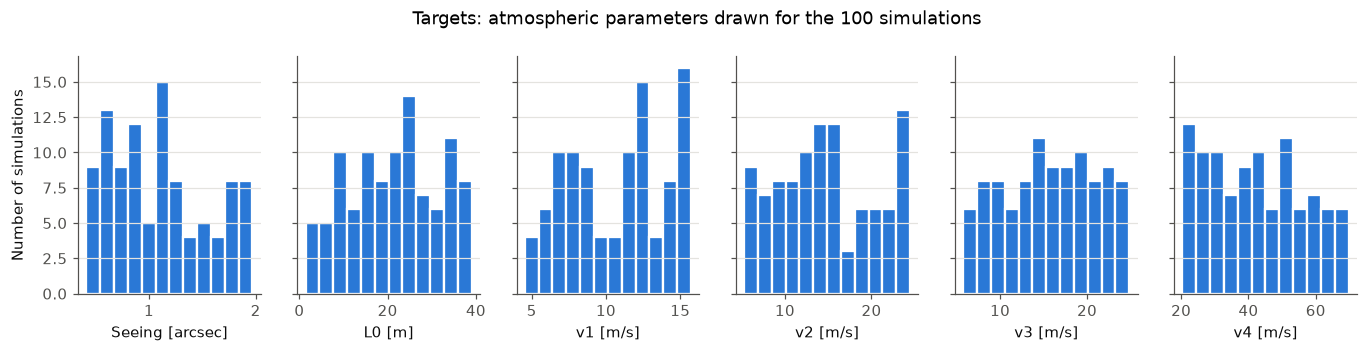

In [5]:
fig, axes = plt.subplots(1, 6, figsize=(15, 2.8), sharey=True)
for i, ax in enumerate(axes):
    ax.hist(y[:, i], bins=12, color=C_TRAIN, edgecolor='white', linewidth=1.5)
    ax.set_xlabel(TARGET_LABELS[i])
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('Number of simulations')
fig.suptitle('Targets: atmospheric parameters drawn for the 100 simulations', y=1.03)
plt.show()

All six parameters were drawn from **uniform** distributions, so the histograms are roughly flat. With only 100 samples they are noisy, and there are gaps. Keep this in mind: 100 examples is a **very small** dataset for machine learning.

### 2.3 Look at the raw simulation output of one sample

Before we reduce each simulation to three numbers, let us look at what is behind them. We compare the simulations with the **best** and the **worst** seeing.

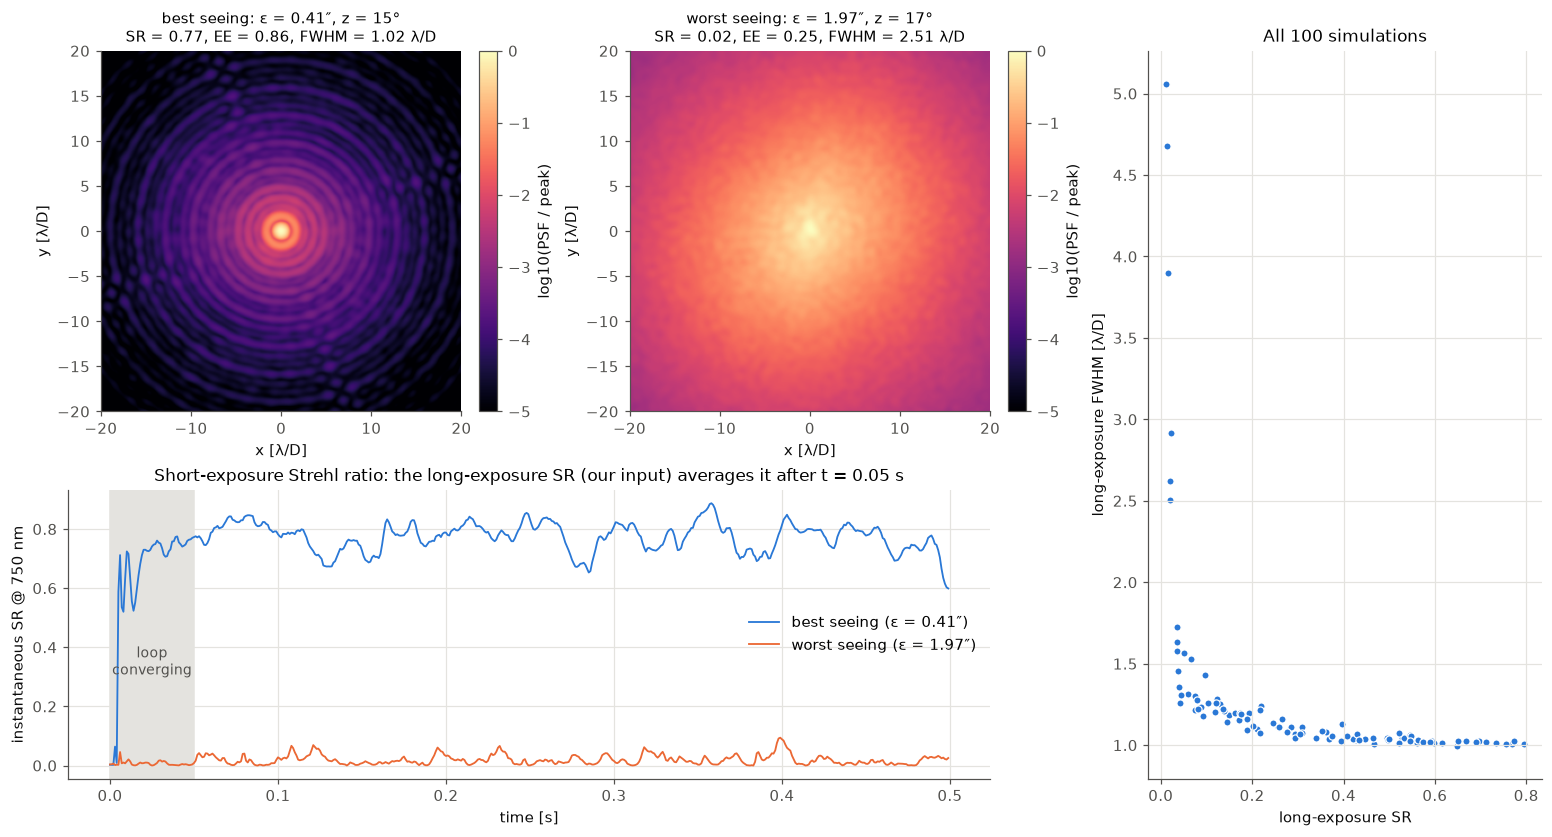

1 λ/D at 750 nm ≈ 85 mas


In [6]:
i_good, i_bad = np.argmin(y[:, 0]), np.argmax(y[:, 0])
LAMBDA_D_MAS = 750e-9 / 1.82 * 206265e3        # 1 λ/D in milliarcsec
ND = 8                                         # PSF sampling: 8 pixels per λ/D (psf.nd in the yml)
half = 20 * ND                                 # show ±20 λ/D around the centre
t = np.arange(500) * 1e-3                      # 1 kHz loop, 0.5 s

fig = plt.figure(figsize=(14, 7.5), layout='constrained')
gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.8])
for col, (idx, tag) in enumerate([(i_good, 'best seeing'), (i_bad, 'worst seeing')]):
    psf = fits.getdata(sample_paths[idx] / 'psfint.fits').squeeze()
    c = np.array(psf.shape) // 2
    cut = psf[c[0]-half:c[0]+half, c[1]-half:c[1]+half]
    ax = fig.add_subplot(gs[0, col])
    ext = np.array([-half, half, -half, half]) / ND
    im = ax.imshow(np.log10(cut / cut.max()), extent=ext, vmin=-5, vmax=0, cmap='magma', origin='lower')
    ax.set_title(f'{tag}: ε = {y[idx,0]:.2f}″, z = {zenith[idx]:.0f}°\n'
                 f'SR = {X[idx,0]:.2f}, EE = {X[idx,1]:.2f}, FWHM = {X[idx,2]:.2f} λ/D', fontsize=10)
    ax.set_xlabel('x [λ/D]'); ax.set_ylabel('y [λ/D]'); ax.grid(False)
    fig.colorbar(im, ax=ax, label='log10(PSF / peak)', fraction=0.046, pad=0.02)

# frame-by-frame Strehl ratio: shows the loop closing and converging
ax = fig.add_subplot(gs[1, :2])
for idx, color, tag in [(i_good, C_TRAIN, 'best seeing'), (i_bad, C_VAL, 'worst seeing')]:
    sr_t = fits.getdata(sample_paths[idx] / 'sr.fits').squeeze()
    ax.plot(t, sr_t, color=color, lw=1.2, label=f'{tag} (ε = {y[idx,0]:.2f}″)')
ax.axvspan(0, 0.05, color='#e4e3df', zorder=0)
ax.text(0.025, 0.35, 'loop\nconverging', ha='center', va='center', fontsize=9, color=C_REF)
ax.set_xlabel('time [s]'); ax.set_ylabel('instantaneous SR @ 750 nm'); ax.legend(loc='center right')
ax.set_title('Short-exposure Strehl ratio: the long-exposure SR (our input) averages it after t = 0.05 s')

# the two main inputs for all simulations
ax = fig.add_subplot(gs[:, 2])
ax.scatter(X[:, 0], X[:, 2], s=22, color=C_TRAIN, edgecolor='white', linewidth=0.8)
ax.set_xlabel('long-exposure SR'); ax.set_ylabel('long-exposure FWHM [λ/D]')
ax.set_title('All 100 simulations')
plt.show()
print(f'1 λ/D at 750 nm ≈ {LAMBDA_D_MAS:.0f} mas')

**What we see**

- With good seeing the PSF has a sharp, diffraction-limited core and Airy rings. The AO correction works well.
- With bad seeing much of the light goes into the uncorrected **halo**, and the Strehl ratio drops.
- The instantaneous SR starts close to zero (open loop), rises while the loop converges, and then fluctuates. The long-exposure metrics are accumulated only after 0.05 s.
- SR and FWHM are strongly related to each other (right panel). The three inputs are **not independent**: they are three summaries of the same PSF.

---
## 3. Explore the data: which parameters are "visible" in the inputs?

Before we train a network, we check if the information is there at all. We plot every input against every target and write the **Spearman rank correlation** $\rho$ in each panel. $\rho$ measures any monotonic relation: $|\rho| \approx 1$ is a strong relation, $\rho \approx 0$ means no monotonic relation.

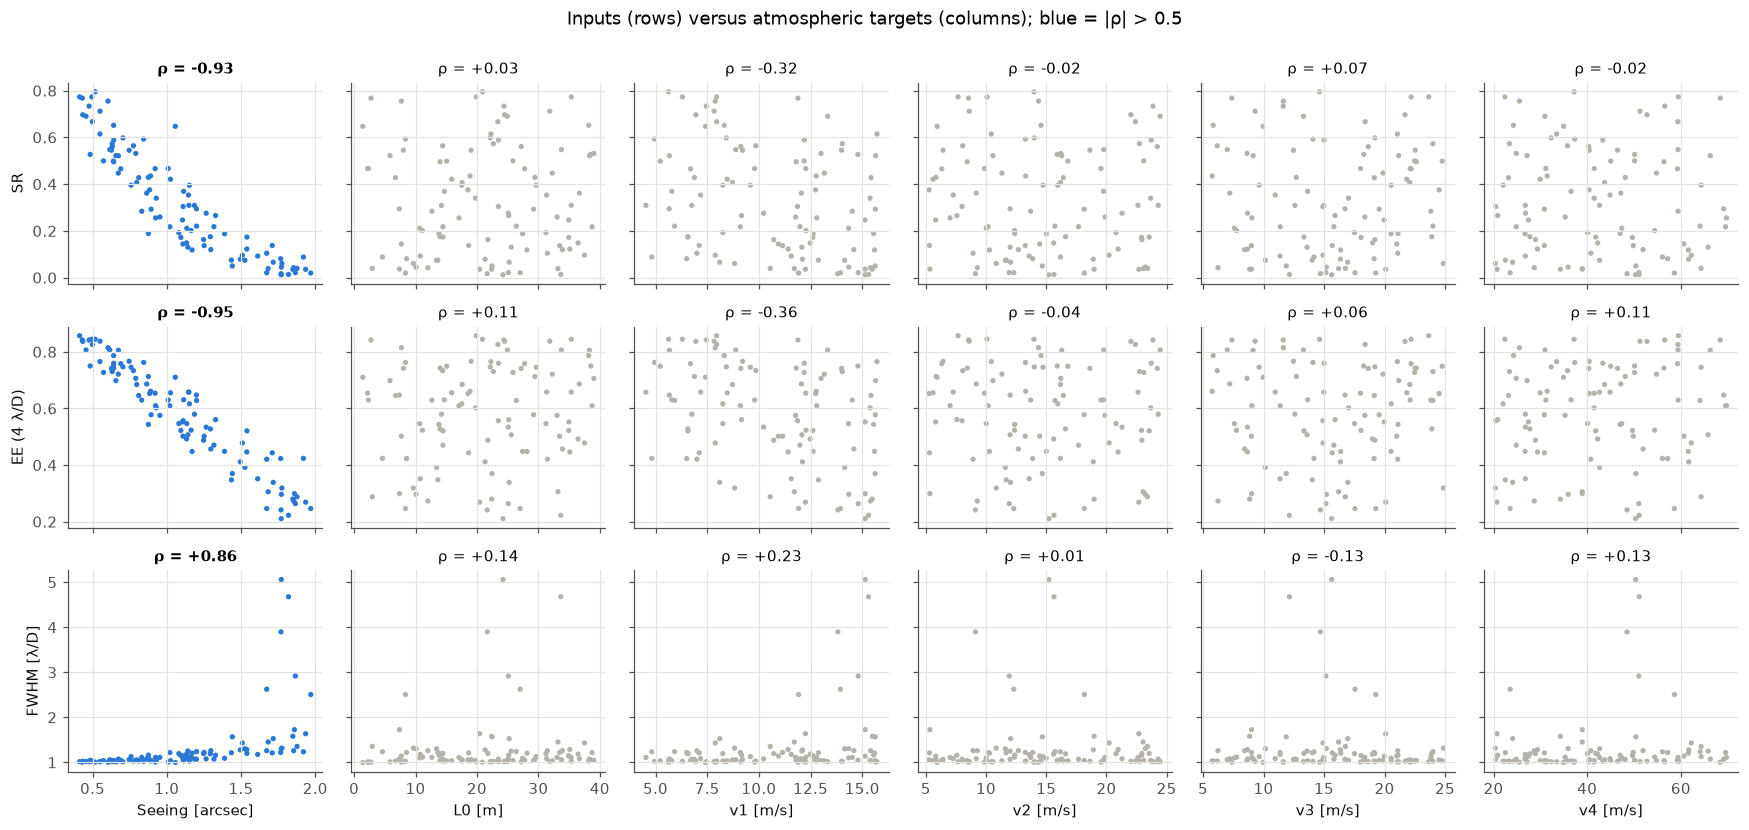

In [7]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(3, 6, figsize=(16, 7.5), sharex='col', sharey='row')
for r in range(3):
    for c in range(6):
        ax = axes[r, c]
        rho = spearmanr(y[:, c], X[:, r])[0]
        strong = abs(rho) > 0.5
        ax.scatter(y[:, c], X[:, r], s=12, color=C_TRAIN if strong else '#b4b2a9', edgecolor='none')
        ax.set_title(f'ρ = {rho:+.2f}', fontsize=10, fontweight='bold' if strong else 'normal')
        if r == 2: ax.set_xlabel(TARGET_LABELS[c])
        if c == 0: ax.set_ylabel(INPUT_NAMES[r])
fig.suptitle('Inputs (rows) versus atmospheric targets (columns); blue = |ρ| > 0.5', y=1.0)
plt.tight_layout(); plt.show()

**Interpretation: this is the most important plot of the tutorial.**

- **Seeing** is strongly visible in all three inputs ($|\rho| \approx 0.9$). Worse seeing gives lower SR, lower EE and a wider PSF, as expected from the $(D/r_0)^{5/3}$ scaling. We expect the network to predict seeing well.
- **$v_1$** (the ground layer, ≈ 70 % of the turbulence) has a weak signature ($|\rho| \approx 0.3$). A faster ground layer gives a larger servo-lag error and so a lower SR.
- **$L_0$, $v_2$, $v_3$, $v_4$** give almost no signal. These layers carry little turbulence, and $L_0$ changes mostly tip-tilt, which the AO loop corrects well. Their effect on SR, EE and FWHM is smaller than the effect of seeing, zenith angle and noise.

We also see some scatter even in the seeing panels. Part of it comes from the **nuisance parameters**. For example, the same seeing at a larger zenith angle means more turbulence along the line of sight:

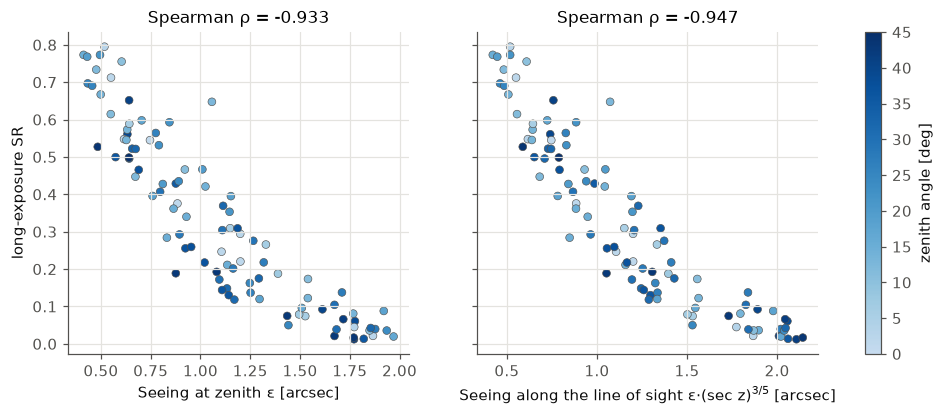

In [8]:
from matplotlib.colors import ListedColormap
zen_cmap = ListedColormap(plt.cm.Blues(np.linspace(0.25, 1, 256)))    # one hue, light -> dark, no near-white points
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
seeing_eff = y[:, 0] / np.cos(np.radians(zenith)) ** 0.6       # ε·(sec z)^{3/5}
for ax, xval, xlabel in [(axes[0], y[:, 0], 'Seeing at zenith ε [arcsec]'),
                         (axes[1], seeing_eff, 'Seeing along the line of sight ε·(sec z)$^{3/5}$ [arcsec]')]:
    sc = ax.scatter(xval, X[:, 0], c=zenith, cmap=zen_cmap, vmin=0, vmax=45, s=26, edgecolor='#52514e', linewidth=0.4)
    ax.set_xlabel(xlabel)
    ax.set_title(f'Spearman ρ = {spearmanr(xval, X[:, 0])[0]:+.3f}')
axes[0].set_ylabel('long-exposure SR')
fig.colorbar(sc, ax=axes, label='zenith angle [deg]')
plt.show()

With the airmass correction the relation becomes tighter. Zenith angle is a hidden variable that the network does not see, and it adds "noise" to our inverse problem. (**Exercise idea:** give the zenith angle to the network as a 4th input. At a real telescope it is always known!)

**Expectation before training:** the NN should retrieve seeing well, $v_1$ perhaps a little, and for the other parameters it will do about as well as always predicting the average value. Machine learning cannot create information that is not in the inputs.

---
## 4. Pre-processing

Neural networks train best when inputs and outputs are **numbers of order 1, centred on zero**. Our raw quantities have very different scales: SR is between 0.01 and 0.8, FWHM between 1 and 5, $L_0$ between 1 and 40 m. The squared-error loss would be dominated by the targets with large numbers (the wind speeds, $L_0$) and would almost ignore seeing.

We apply the same pre-processing as `ml_workflow/configs/preprocessing/zscore.yaml` (implemented in `ml_workflow/preprocessing/normalizer.py`):

1. **Log transform of the inputs** ($x \to \log x$). SR spans almost two orders of magnitude and is very skewed. The log spreads the values evenly. It is also physically motivated: in the Maréchal approximation $\mathrm{SR} \approx e^{-\sigma^2}$, so $\log \mathrm{SR}$ is linear in the residual wavefront variance $\sigma^2$.
2. **Z-score standardisation** of inputs and targets: $\;x' = (x-\mu)/\sigma$.

> ⚠️ **Data leakage.** $\mu$ and $\sigma$ must be computed **on the training set only**. If we used the whole dataset, a little information about the test set would go into the model, and the test score would look better than it really is. That is why we split first (Section 5) and compute the statistics afterwards.

Here we only **look** at the effect of the log transform on the input distributions:

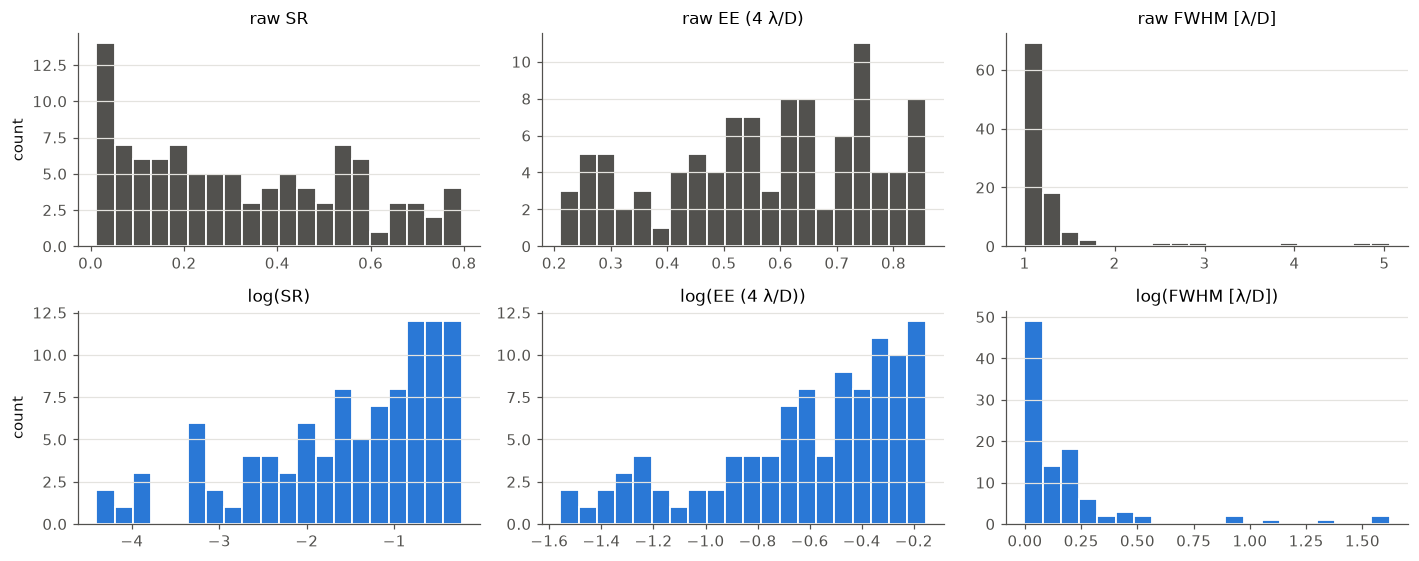

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 5.2))
for j in range(3):
    axes[0, j].hist(X[:, j], bins=20, color=C_REF, edgecolor='white', linewidth=1.2)
    axes[0, j].set_title(f'raw {INPUT_NAMES[j]}')
    axes[1, j].hist(np.log(X[:, j]), bins=20, color=C_TRAIN, edgecolor='white', linewidth=1.2)
    axes[1, j].set_title(f'log({INPUT_NAMES[j]})')
for ax in axes.flat: ax.grid(axis='x', visible=False)
axes[0, 0].set_ylabel('count'); axes[1, 0].set_ylabel('count')
plt.tight_layout(); plt.show()

The log spreads out the many low-SR samples, which were squeezed near 0. FWHM stays skewed even after the log, and this is physical. Whenever the AO system keeps a diffraction-limited core, the FWHM saturates at ≈ 1 $\lambda/D$. Only when the correction is poor (SR ≲ 0.05) does it jump to 2–5 $\lambda/D$. So FWHM carries information only in the bad-seeing regime, while SR and EE are informative everywhere.

## 5. Split the data: train / validation / test

We divide the 100 simulations into three **disjoint** sets. Each set has a different job:

| Set | Used for | Does the model learn from it? |
|---|---|---|
| **Training** | Updating the network weights (gradient descent) | Yes |
| **Validation** | Monitoring training: selecting the best epoch, tuning hyper-parameters, detecting over-fitting | Indirectly (we make choices with it) |
| **Test** | One final, honest estimate of the performance on new data | **No. Look at it only at the end** |

The Hydra config (`ml_workflow/configs/config.yaml`) uses 90 / 5 / 5 %. That is fine for a large dataset, but with 100 samples it gives only 5 validation and 5 test samples, and the metrics would be very noisy. Here we use **70 / 15 / 15**. The split is random, with a fixed seed.

In [10]:
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15

indices = np.arange(len(X))
train_idx, rest_idx = train_test_split(indices, test_size=VAL_FRAC + TEST_FRAC, random_state=SEED)
val_idx, test_idx   = train_test_split(rest_idx, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC), random_state=SEED)
assert not (set(train_idx) & set(val_idx) or set(train_idx) & set(test_idx) or set(val_idx) & set(test_idx))
print(f'train: {len(train_idx)}   validation: {len(val_idx)}   test: {len(test_idx)}')

train: 70   validation: 15   test: 15


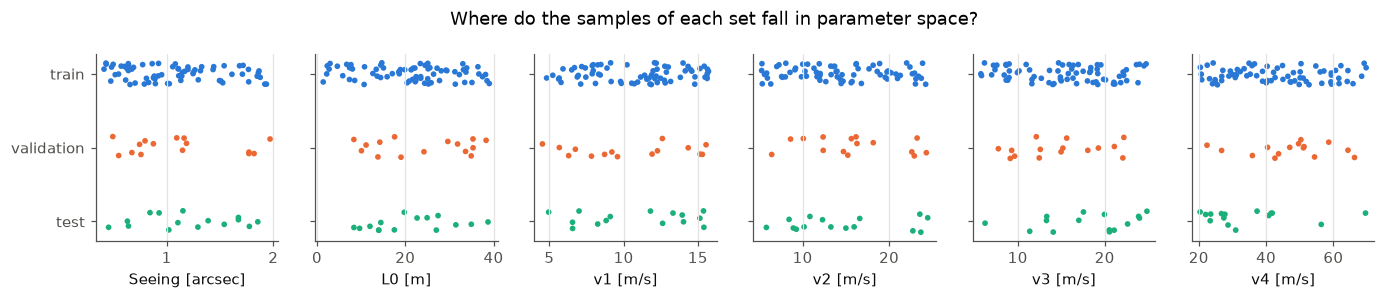

In [11]:
# Check: do the three sets cover the same parameter range? (A test value far outside the training range
# would be an extrapolation, and neural networks are bad at extrapolating.)
fig, axes = plt.subplots(1, 6, figsize=(15, 2.2), sharey=True)
for i, ax in enumerate(axes):
    for k, (idx, color, name) in enumerate([(train_idx, C_TRAIN, 'train'), (val_idx, C_VAL, 'validation'),
                                            (test_idx, C_TEST, 'test')]):
        ax.scatter(y[idx, i], np.full(len(idx), k) + np.random.uniform(-0.15, 0.15, len(idx)),
                   s=14, color=color, edgecolor='none')
    ax.set_xlabel(TARGET_LABELS[i]); ax.grid(axis='y', visible=False)
axes[0].set_yticks([0, 1, 2], ['train', 'validation', 'test']); axes[0].invert_yaxis()
fig.suptitle('Where do the samples of each set fall in parameter space?', y=1.06)
plt.show()

### 5.1 Fit the normalisation on the training set, then apply it to all sets

In [12]:
# 1) log of the inputs
X_log = np.log(X + 1e-12)

# 2) statistics from the TRAINING set only
x_mean, x_std = X_log[train_idx].mean(0), X_log[train_idx].std(0)
y_mean, y_std = y[train_idx].mean(0),     y[train_idx].std(0)
x_std[x_std == 0] = 1; y_std[y_std == 0] = 1

# 3) the same transformation for every set
Xn = (X_log - x_mean) / x_std
yn = (y - y_mean) / y_std

def denormalize_y(yn_):                    # back to physical units (used at test time)
    return yn_ * y_std + y_mean

print('normalised train inputs : mean', Xn[train_idx].mean(0).round(3), ' std', Xn[train_idx].std(0).round(3))
print('normalised train targets: mean', yn[train_idx].mean(0).round(3), ' std', yn[train_idx].std(0).round(3))
print('normalised test  targets: mean', yn[test_idx].mean(0).round(2), '  (not exactly 0: expected, and correct)')

normalised train inputs : mean [0. 0. 0.]  std [1. 1. 1.]
normalised train targets: mean [ 0. -0.  0.  0.  0. -0.]  std [1. 1. 1. 1. 1. 1.]
normalised test  targets: mean [ 0.27  0.02  0.    0.05  0.49 -0.62]   (not exactly 0: expected, and correct)


### 5.2 PyTorch `Dataset` and `DataLoader`

PyTorch reads the data through a `DataLoader`. It gives the network **mini-batches** of samples, and it can shuffle the training set at each epoch (shuffling makes stochastic gradient descent work better). In `ml_workflow` this is done by `make_dataloaders()` in `dataset/dataset.py`.

In [13]:
BATCH_SIZE = 16

def make_loader(idx, shuffle):
    ds = TensorDataset(torch.tensor(Xn[idx]), torch.tensor(yn[idx]))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)

train_loader = make_loader(train_idx, shuffle=True)
val_loader   = make_loader(val_idx,   shuffle=False)
test_loader  = make_loader(test_idx,  shuffle=False)

xb, yb = next(iter(train_loader))
print('one batch -> inputs', tuple(xb.shape), ' targets', tuple(yb.shape))

one batch -> inputs (16, 3)  targets (16, 6)


## 6. The neural network

We use a **fully-connected (dense) neural network**, also called a multi-layer perceptron (MLP). It is the same model as `ml_workflow/models/dense_nn.py` (`DenseNN`), and we import it from there:

```
 input (3)            hidden 1 (1024)        hidden 2 (16)          output (6)
 log SR   ─┐                                                       ┌─ seeing
 log EE   ─┼─► Linear ─► ReLU ─────► Linear ─► ReLU ─────► Linear ─┼─ L0
 log FWHM ─┘   3×1024+1024           1024×16+16            16×6+6   └─ v1 v2 v3 v4
```

- Each **Linear** layer computes $\mathbf{h} = W\mathbf{x} + \mathbf{b}$. The weights $W$ and biases $\mathbf{b}$ are the parameters that training adjusts.
- **ReLU** $(\max(0, h))$ is the non-linearity. Without it, the stack of layers would be one linear regression. With it, the network can approximate non-linear relations, like SR ∝ $e^{-(D/r_0)^{5/3}}$.
- The **output layer has no activation**, because this is **regression**: the outputs are any real numbers (normalised physical quantities).
- The 6 outputs share the same hidden layers (**multi-output regression**). The network learns one common representation of "the state of the turbulence" and reads all the parameters from it.

**Loss function:** mean squared error on the *normalised* targets, averaged over the 6 parameters:
$$\mathcal{L} = \frac{1}{6N}\sum_{n=1}^{N}\sum_{k=1}^{6}\left(\hat y'_{nk} - y'_{nk}\right)^2 .$$
Because the targets are standardised, **a loss of 1.0 means "no better than always predicting the mean"**. This is our baseline.

**Optimiser:** Adam, learning rate $10^{-3}$ (`configs/optimizer/adam.yaml`). It is an adaptive version of stochastic gradient descent.

In [14]:
from models.dense_nn import DenseNN

torch.manual_seed(SEED)
model = DenseNN(neurons_first_hidden_layers=1024).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f'\nTrainable parameters: {n_params:,}   vs   training samples: {len(train_idx)} × 6 targets')

DenseNN(
  (fc1): Linear(in_features=3, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=6, bias=True)
)

Trainable parameters: 20,598   vs   training samples: 70 × 6 targets


The network has more than 20 000 free parameters and we have only 70 × 6 = 420 target values. A model this flexible can **memorise** the training set (over-fitting). The validation set will show us if this happens.

---
## 7. Training and validation

Each **epoch** is one full pass over the training set:

1. **Training phase** (`model.train()`): for every mini-batch
   - *forward pass*: compute the predictions and the loss,
   - *backward pass*: `loss.backward()` computes $\partial\mathcal{L}/\partial W$ for every weight (back-propagation),
   - *update*: `optimizer.step()` moves the weights a small step against the gradient.
2. **Validation phase** (`model.eval()`, `torch.no_grad()`): compute the loss on the validation set **without** changing the weights.

We keep the weights of the epoch with the **lowest validation loss** (*checkpointing on the best validation loss*, as in `ml_workflow/train_utils.py`). This is a simple form of **early stopping**: if the model starts to over-fit later, we still keep the best version.

### 7.1 Pretrained model or train your own?

To save time during the school, **a pretrained model is loaded by default**. It was trained with exactly the code below: same data, same split, same settings. Read the training function carefully anyway, because it is the heart of the tutorial. When you want to experiment (Section 11), switch to training it yourself.

The next cell only **defines** three functions:

| Function | What it does |
|---|---|
| `train_model(epochs, save_path=None)` | Runs the training loop and restores the best-validation weights. If `save_path` is given, it also saves the result there |
| `save_checkpoint(path, ...)` | Saves the weights **plus** the normalisation statistics, the data split and the learning curves |
| `load_pretrained_model(path)` | Loads a saved model. It first checks that the dataset and split are the same as when the model was trained (otherwise the "test" set might contain training samples) |

In [15]:
PRETRAINED_PATH = PROJECT_ROOT / 'pretrained_models' / 'dnn_atmo_retrieval.pt'
EPOCHS = 300

def run_epoch(loader, train):
    # One pass over a loader. Returns the sample-weighted mean loss.
    model.train(train)
    total, n = 0.0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item() * len(xb); n += len(xb)
    return total / n


def train_model(epochs=EPOCHS, save_path=None):
    # Train `model`, keep the weights with the lowest validation loss, optionally save them.
    history = {'train': [], 'val': []}
    best_val, best_epoch, best_state = float('inf'), -1, None

    for epoch in range(epochs):
        train_loss = run_epoch(train_loader, train=True)
        val_loss   = run_epoch(val_loader,   train=False)
        history['train'].append(train_loss); history['val'].append(val_loss)

        if val_loss < best_val:                                     # checkpoint on best validation loss
            best_val, best_epoch = val_loss, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 30 == 0 or epoch == epochs - 1:
            print(f'epoch {epoch+1:3d}/{epochs} | train loss {train_loss:.4f} | val loss {val_loss:.4f}')

    model.load_state_dict(best_state)
    print(f'\nBest validation loss {best_val:.4f} at epoch {best_epoch+1}: these weights are restored.')

    if save_path is not None:
        save_checkpoint(save_path, history, best_epoch, best_val)
    return history, best_epoch, best_val


def save_checkpoint(path, history, best_epoch, best_val):
    # Everything needed to reuse the model later, not only the weights.
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        'model': {k: v.cpu() for k, v in model.state_dict().items()},
        'model_kwargs': {'neurons_first_hidden_layers': 1024},
        'epoch': best_epoch, 'best_val_loss': best_val, 'history': history,
        'normalizer': {'input_log': True, 'input_mean': x_mean, 'input_std': x_std,
                       'output_mean': y_mean, 'output_std': y_std},
        'split': {'seed': SEED, 'train': train_idx, 'val': val_idx, 'test': test_idx},
        'samples': [str(p.relative_to(DATA_ROOT)) for p in sample_paths],
        'input_names': INPUT_NAMES, 'target_names': TARGET_NAMES, 'target_units': TARGET_UNITS,
    }, path)
    print('Model saved to', path)


def load_pretrained_model(path=PRETRAINED_PATH):
    # Load saved weights into `model`, after checking that data, split and normalisation match.
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'{path} not found. Ask the tutors for the pretrained model, '
                                'or train your own model (Option B in the next cell).')
    ckpt = torch.load(path, map_location=device, weights_only=False)

    norm = ckpt['normalizer']
    checks = {
        'same simulations': ckpt['samples'] == [str(p.relative_to(DATA_ROOT)) for p in sample_paths],
        'same train/val/test split': all(np.array_equal(ckpt['split'][k], idx) for k, idx in
                                         [('train', train_idx), ('val', val_idx), ('test', test_idx)]),
        'same normalisation': all(np.allclose(norm[k], v) for k, v in
                                  [('input_mean', x_mean), ('input_std', x_std),
                                   ('output_mean', y_mean), ('output_std', y_std)]),
    }
    for name, ok in checks.items():
        print(f'  {"✔" if ok else "✘"} {name}')
    if not all(checks.values()):
        raise RuntimeError('The dataset or the split changed since this model was trained, so its test set '
                           'is not guaranteed to be unseen. Train a new model (Option B).')

    model.load_state_dict(ckpt['model'])
    print(f'Loaded {path.name}: best epoch {ckpt["epoch"]+1}, best validation loss {ckpt["best_val_loss"]:.4f}')
    return ckpt['history'], ckpt['epoch'], ckpt['best_val_loss']

### 7.2 Get a trained model

- **Option A (default):** load the pretrained model.
- **Option B:** train the model yourself. Comment out Option A and uncomment **one** of the two Option B lines. Training takes about a minute on a GPU and a few minutes on a CPU.
  - Students: use the first line. Your model stays in memory and the pretrained file is not touched.
  - Tutors: the second line trains the model and saves it as the pretrained model for the students (`pretrained_models/dnn_atmo_retrieval.pt`).

In [16]:
# ▶ Option A: load the pretrained model (default)
history, best_epoch, best_val = load_pretrained_model(PRETRAINED_PATH)

# ▶ Option B: train the model yourself (uncomment ONE line, and comment out Option A)
# history, best_epoch, best_val = train_model(epochs=EPOCHS)                              # students
# history, best_epoch, best_val = train_model(epochs=EPOCHS, save_path=PRETRAINED_PATH)  # tutors: train + save the pretrained model

# sanity check: recompute the validation loss of the model that is now in memory
print(f'Validation loss of the model in memory: {run_epoch(val_loader, train=False):.4f}')

  ✔ same simulations
  ✔ same train/val/test split
  ✔ same normalisation
Loaded dnn_atmo_retrieval.pt: best epoch 46, best validation loss 0.7064
Validation loss of the model in memory: 0.7064


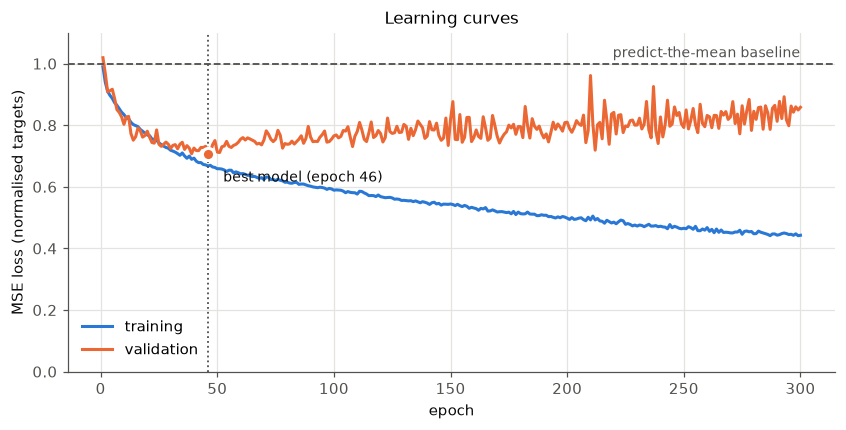

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
ep = np.arange(1, len(history['train']) + 1)
ax.plot(ep, history['train'], color=C_TRAIN, label='training')
ax.plot(ep, history['val'],   color=C_VAL,   label='validation')
ax.axhline(1.0, color=C_REF, ls='--', lw=1.2)
ax.text(ep[-1], 1.01, 'predict-the-mean baseline', va='bottom', ha='right', color=C_REF, fontsize=9)
ax.axvline(best_epoch + 1, color=C_REF, ls=':', lw=1.2)
ax.plot(best_epoch + 1, best_val, 'o', ms=8, color=C_VAL, markeredgecolor='white', markeredgewidth=2)
ax.annotate(f'best model (epoch {best_epoch+1})', (best_epoch + 1, best_val), xytext=(10, -18),
            textcoords='offset points', fontsize=9, color='#0b0b0b')
ax.set_ylim(0, 1.1); ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss (normalised targets)')
ax.set_title('Learning curves'); ax.legend(loc='lower left')
plt.show()

**How to read learning curves**

- **First few tens of epochs:** both curves fall together, from 1.0 (the baseline) to ≈ 0.7. The network learns the part of the problem that *generalises*: mostly the seeing.
- **Why not closer to 0?** The loss is an *average over 6 parameters*. If seeing were predicted perfectly (error ≈ 0) and the other 5 parameters stayed at the baseline (error ≈ 1), the average would be ≈ 5/6 ≈ 0.83. A validation loss of ≈ 0.7 is therefore about what we can expect. The limit comes from the **information in the inputs**, not from the network.
- **After the minimum**, the training loss keeps falling but the validation loss slowly **rises**. This is **over-fitting**: the 20 000 parameters start to memorise the particular noise of the 70 training samples (for example, accidental correlations between SR and $v_2$). These do not generalise to new data. The best-epoch checkpoint (dot) protects us: we keep the weights from before over-fitting started.
- The validation set has only 15 samples, so its curve is noisy. Do not over-interpret single spikes.

---
## 8. Evaluation on the test set

Now, for the first and only time, we use the **test set**: 15 simulations that were not used for training or for choosing the model. We convert the predictions back to **physical units** and compute, for each parameter:

- **MAE**: mean absolute error, in physical units.
- **Baseline MAE**: the MAE if we always predict the *training-set mean*. A useful model must be clearly better than this.
- **$R^2$**: coefficient of determination. 1 is a perfect prediction, 0 is no better than the mean, and < 0 is worse than the mean.

In [18]:
model.eval()
with torch.no_grad():
    pred_test = denormalize_y(model(torch.tensor(Xn[test_idx]).to(device)).cpu().numpy())
true_test = y[test_idx]

def r2(t, p):
    return 1 - ((t - p) ** 2).sum(0) / ((t - t.mean(0)) ** 2).sum(0)

mae      = np.abs(pred_test - true_test).mean(0)
mae_base = np.abs(y_mean - true_test).mean(0)
results = pd.DataFrame({
    'unit': TARGET_UNITS,
    'MAE (NN)': mae,
    'MAE (baseline: mean)': mae_base,
    'improvement': 1 - mae / mae_base,
    'R²': r2(true_test, pred_test),
}, index=TARGET_NAMES)
results.style.format({'MAE (NN)': '{:.3f}', 'MAE (baseline: mean)': '{:.3f}',
                      'improvement': '{:+.0%}', 'R²': '{:+.2f}'})

,unit,MAE (NN),MAE (baseline: mean),improvement,R²
Seeing,arcsec,0.116,0.379,+69%,+0.89
L0,m,7.793,7.892,+1%,+0.07
v1,m/s,3.128,3.302,+5%,+0.07
v2,m/s,5.804,5.159,-12%,-0.20
v3,m/s,5.168,5.106,-1%,-0.22
v4,m/s,10.116,13.936,+27%,+0.14


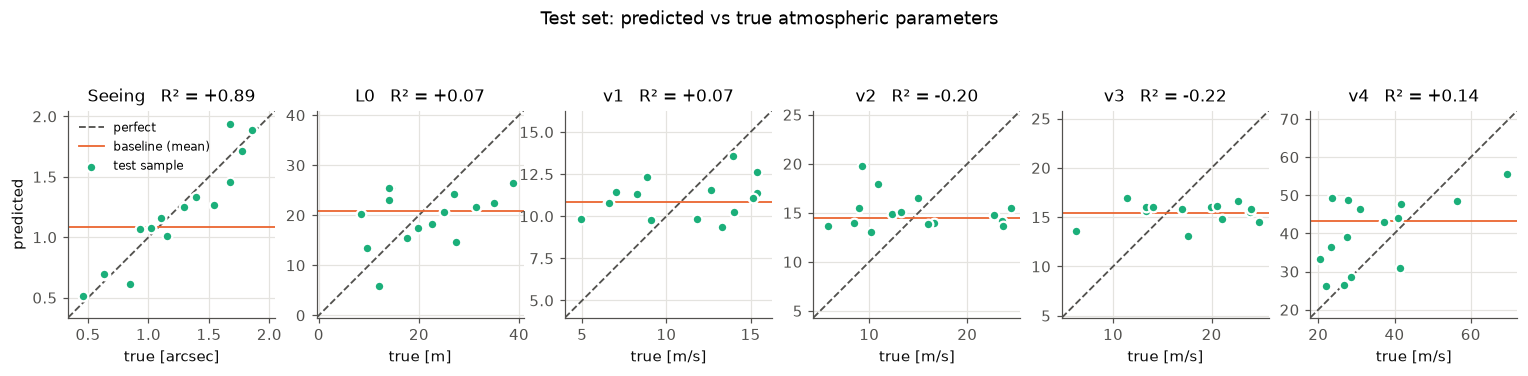

In [19]:
fig, axes = plt.subplots(1, 6, figsize=(17, 3.4))
r2_all = r2(true_test, pred_test)
for i, ax in enumerate(axes):
    lo, hi = y[:, i].min(), y[:, i].max()
    pad = 0.05 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=C_REF, ls='--', lw=1.2, label='perfect')
    ax.axhline(y_mean[i], color=C_VAL, lw=1.2, label='baseline (mean)')
    ax.scatter(true_test[:, i], pred_test[:, i], s=40, color=C_TEST, edgecolor='white', linewidth=1.5, zorder=3,
               label='test sample')
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad); ax.set_aspect('equal')
    ax.set_title(f'{TARGET_NAMES[i]}   R² = {r2_all[i]:+.2f}')
    ax.set_xlabel(f'true [{TARGET_UNITS[i]}]')
axes[0].set_ylabel('predicted')
axes[0].legend(loc='upper left', fontsize=8)
fig.suptitle('Test set: predicted vs true atmospheric parameters', y=1.04)
plt.show()

**Interpretation**

- **Seeing** is retrieved well: the points follow the 1:1 line, $R^2 \approx 0.9$, and the mean absolute error is ≈ 0.1″. That is about 3× better than the baseline, and comparable to the typical disagreement between two seeing monitors. From three numbers that every AO system produces, the network gives a useful seeing estimate *along the line of sight of the science target*.
- For **$L_0$ and the wind speeds** the predictions do **not** follow the 1:1 line. They scatter around the horizontal "mean" line, and $R^2$ is close to 0 (slightly positive or negative). With only 15 test samples, values like ±0.2 are consistent with zero. The scatter of the predictions is the over-fitting noise we saw in the learning curves: the network produces some variation, but it is not related to the true values.
- The 6-output model still performs well on seeing: the shared hidden layers let each output use what it needs.
- This is not a failure of machine learning. The **inputs do not contain the information**, as we saw in Section 3. This is the most important lesson of the tutorial: *explore your data before you train, and always compare with a baseline.*

Let us look more closely at the seeing errors. Is there structure in the residuals?

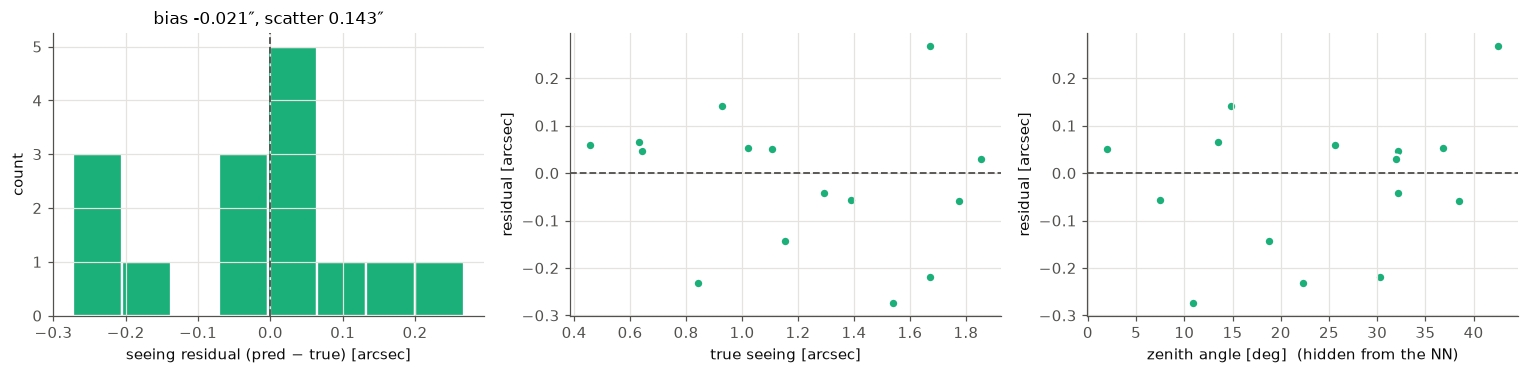

In [20]:
res = pred_test[:, 0] - true_test[:, 0]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].hist(res, bins=8, color=C_TEST, edgecolor='white', linewidth=1.5)
axes[0].axvline(0, color=C_REF, ls='--', lw=1.2)
axes[0].set_xlabel('seeing residual (pred − true) [arcsec]'); axes[0].set_ylabel('count')
axes[0].set_title(f'bias {res.mean():+.3f}″, scatter {res.std():.3f}″')
for ax, xval, xlabel in [(axes[1], true_test[:, 0], 'true seeing [arcsec]'),
                         (axes[2], zenith[test_idx], 'zenith angle [deg]  (hidden from the NN)')]:
    ax.axhline(0, color=C_REF, ls='--', lw=1.2)
    ax.scatter(xval, res, s=40, color=C_TEST, edgecolor='white', linewidth=1.5)
    ax.set_xlabel(xlabel); ax.set_ylabel('residual [arcsec]')
plt.tight_layout(); plt.show()

Look for patterns:
- A trend of the residual with **zenith angle** would show that the network sees the *line-of-sight* seeing but not the zenith seeing. It cannot know the difference because $z$ is not an input.
- Larger errors at **large seeing** are expected. When the correction is poor, SR changes little with seeing (SR is already close to 0), so the inputs are less sensitive to it.

With only 15 test points these trends are only hints. A bigger dataset would make them clear.

---
## 9. Saving and reusing a model

A model is only useful if we can use it again later. `save_checkpoint()` (Section 7) stores the weights **together with the normalisation statistics**. Without $\mu$ and $\sigma$ nobody can pre-process new data in the same way, and the predictions would be meaningless. It also stores the split and the learning curves, so that the results can be reproduced. Let us look inside the pretrained checkpoint:

In [21]:
ckpt = torch.load(PRETRAINED_PATH, map_location='cpu', weights_only=False)
for key, value in ckpt.items():
    summary = f'dict with keys {list(value)}' if isinstance(value, dict) else \
              f'list of {len(value)} items' if isinstance(value, list) else value
    print(f'{key:14s}: {summary}')

# If you trained your own model (Option B), you can keep it in a file of your own:
# save_checkpoint(WORKFLOW_ROOT / 'outputs' / 'notebook' / 'my_model.pt', history, best_epoch, best_val)

model         : dict with keys ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias']
model_kwargs  : dict with keys ['neurons_first_hidden_layers']
epoch         : 45
best_val_loss : 0.7064092755317688
history       : dict with keys ['train', 'val']
normalizer    : dict with keys ['input_log', 'input_mean', 'input_std', 'output_mean', 'output_std']
split         : dict with keys ['seed', 'train', 'val', 'test']
samples       : list of 100 items
input_names   : list of 3 items
target_names  : list of 6 items
target_units  : list of 6 items


### 9.1 Use the saved model: inference on a "new observation"

This is how the model would be used at the telescope. Load the checkpoint, pre-process the three measured values **with the stored statistics**, predict, and convert back to physical units. It uses only the file: nothing from the notebook's memory.

In [22]:
checkpoint_path = PRETRAINED_PATH            # or the path of your own saved model
ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
retrieval_model = DenseNN(**ckpt['model_kwargs']); retrieval_model.load_state_dict(ckpt['model']); retrieval_model.eval()
norm = ckpt['normalizer']

def retrieve_atmosphere(sr, ee, fwhm):
    x = (np.log(np.array([sr, ee, fwhm], dtype=np.float32) + 1e-12) - norm['input_mean']) / norm['input_std']
    with torch.no_grad():
        out = retrieval_model(torch.tensor(x)[None]).numpy()[0]
    return out * norm['output_std'] + norm['output_mean']

k = test_idx[0]                                     # pretend this test simulation is a new observation
estimate = retrieve_atmosphere(*X[k])
print(f'Measured: SR = {X[k,0]:.3f}, EE = {X[k,1]:.3f}, FWHM = {X[k,2]:.2f} λ/D\n')
print(pd.DataFrame({'true': y[k], 'retrieved': estimate}, index=TARGET_LABELS).round(2))

Measured: SR = 0.104, EE = 0.421, FWHM = 1.26 λ/D

                      true  retrieved
Seeing [arcsec]   1.670000   1.450000
L0 [m]           31.469999  21.719999
v1 [m/s]          7.000000  11.440000
v2 [m/s]          8.930000  15.470000
v3 [m/s]         21.090000  14.850000
v4 [m/s]         40.779999  43.990002


---
## 10. Summary and take-home messages

1. **Formulate the problem physically.** We learned an *inverse model* from AO performance metrics (SR, EE, FWHM) to atmospheric parameters (ε, L0, v1…v4), with training data from an end-to-end simulator.
2. **Look at the data first.** Plots of the targets, of raw PSFs and of inputs against targets told us *before training* that only seeing (and, weakly, the ground-layer wind speed) is encoded in the inputs.
3. **Pre-process carefully.** Log-transform the skewed inputs, standardise everything, and compute the statistics **on the training set only**.
4. **Use three disjoint sets.** Train on one, select the model on the second, report on the third. Never tune on the test set.
5. **Always compare with a baseline.** Here "predict the mean" showed clearly where the network adds value (seeing) and where it does not (L0, wind speeds).
6. **The information content of the inputs sets the limit.** A bigger network cannot recover parameters whose effect is not in the data.

## 11. Exercises

1. **Hyper-parameters.** Switch to Option B in Section 7.2 (train yourself), then change `EPOCHS`, the learning rate, `BATCH_SIZE` or `neurons_first_hidden_layers`. Do you get a better validation loss? Is the model over-fitting? (Tip: try a much smaller network, e.g. 32 neurons.)
2. **Add a known quantity.** Add the zenith angle (always known at the telescope) and/or the NGS magnitude as extra inputs. You need to change the first layer to `nn.Linear(4, …)`. Does the seeing retrieval improve? Compare the residual-vs-zenith plot.
3. **Predict only what is possible.** Train a network with a single output (seeing), or with (seeing, $v_1$). Is it better than the 6-output model?
4. **Use richer inputs.** Three scalars are a strong compression. `comm.fits` contains the DM commands (500 steps × 400 modes). The function `load_rms_commands` in `dataset_utils.py` reduces them to the RMS of each mode (400 inputs, see the commented line in `DenseNN`). The *time series* (`sr.fits`, or the modal commands themselves) contain **temporal** information, and temporal information is where wind speed lives. Which input would you use to retrieve $v_1…v_4$? Why is 100 samples a problem for 400 inputs?
5. **Cross-validation.** With 100 samples the test score depends on the random split. Repeat the split with different seeds (or use k-fold cross-validation) and report the mean and scatter of $R^2$ for seeing.
6. **Run the production pipeline.** From `ml_workflow/`, run `python main.py` (Hydra). Compare its config (`configs/config.yaml`) with the choices made in this notebook: split fractions, epochs, input normalisation. Where are the normalisation statistics computed in `train.py`, and is there a risk of data leakage?